# HUMAN ACTION RECOGNITION

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import os

In [39]:
test_dir = r"C:\DATA_SCIENCE\Final_Projects\DeepLearning\Dataset\test"
train_dir = r""C:\DATA_SCIENCE\Final_Projects\DeepLearning\Dataset\train"

In [40]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 
)

test_datagen = ImageDataGenerator(rescale=1./255) 

In [41]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3432 images belonging to 6 classes.
Found 852 images belonging to 6 classes.
Found 756 images belonging to 6 classes.


In [42]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(256,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=6, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 15, 15, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       1,605,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,994,950 (7.61 MB)

 Trainable params: 1,994,950 (7.61 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator
)

Epoch 1/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 105s 949ms/step - accuracy: 0.1748 - loss: 1.7836 - val_accuracy: 0.1784 - val_loss: 1.7823
Epoch 2/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 75s 697ms/step - accuracy: 0.2494 - loss: 1.7400 - val_accuracy: 0.3157 - val_loss: 1.6567
Epoch 3/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 72s 666ms/step - accuracy: 0.3182 - loss: 1.6399 - val_accuracy: 0.3638 - val_loss: 1.5228
Epoch 4/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 74s 684ms/step - accuracy: 0.3520 - loss: 1.5649 - val_accuracy: 0.3873 - val_loss: 1.5144
Epoch 5/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 88s 810ms/step - accuracy: 0.3767 - loss: 1.5233 - val_accuracy: 0.4401 - val_loss: 1.4909
Epoch 6/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 74s 685ms/step - accuracy: 0.3974 - loss: 1.4964 - val_accuracy: 0.4460 - val_loss: 1.4040
Epoch 7/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 72s 670ms/step - accuracy: 0.4251 - loss: 1.4524 - val_accuracy: 0.4707 - val_loss: 1.3371
Epoch 8/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 85s 790ms/step - accuracy: 0.4423 - loss: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


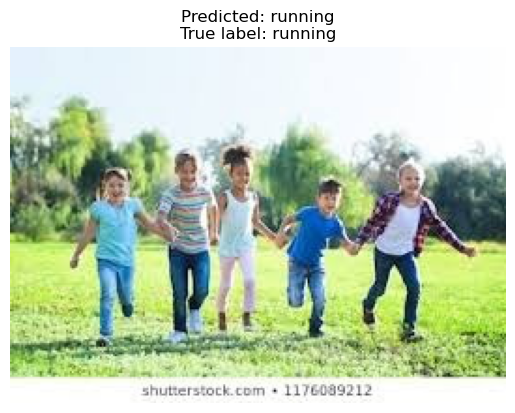

In [70]:
image_path = r"C:\DATA_SCIENCE\Final_Projects\DeepLearning\Dataset\test\running\Image_12147.jpg"
true_class = os.path.basename(os.path.dirname(image_path))
sample_image = plt.imread(image_path)
sample_image_resized = tf.image.resize(sample_image, (150,150))
sample_image_resized = sample_image_resized / 255.0
sample_image_resized = np.expand_dims(sample_image_resized, axis=0)
prediction = model.predict(sample_image_resized)
predicted_class = np.argmax(prediction)
class_names = list(train_generator.class_indices.keys())
plt.imshow(sample_image)
plt.title(f"Predicted: {class_names[predicted_class]}\nTrue label: {true_class}")
plt.axis('off')
plt.show()